In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [3]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [4]:
# 검증 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [6]:
from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.FashionMNIST(root='data', train=True, download=True,
transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True,
transform=ToTensor())


100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



In [7]:
class_list = train_dataset.classes
class_list


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

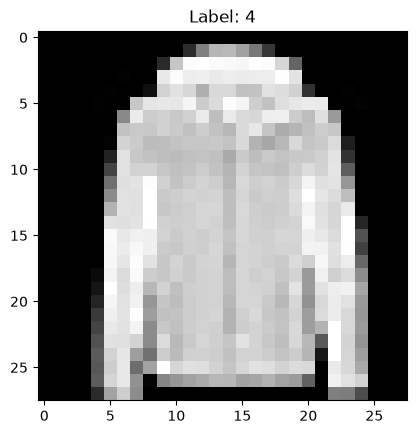

In [8]:
n = 5000
image, label = train_dataset.data[n], train_dataset.targets[n]


# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()


In [9]:
x_train = train_dataset.data / 255
y_train = train_dataset.targets
x_test = test_dataset.data / 255
y_test = test_dataset.targets


In [10]:
#데이터가 너무 많아서 60000 -> 20000 개로 줄임
x_train = x_train[:20000]
y_train = y_train[:20000]
print(x_train.shape)


torch.Size([20000, 28, 28])


In [11]:
x_val, x_test = x_test[:5000], x_test[5000:]
y_val, y_test = y_test[:5000], y_test[5000:]
print(x_val.shape, x_test.shape)


torch.Size([5000, 28, 28]) torch.Size([5000, 28, 28])


In [ ]:
#4차원으로 바꿔줌 
x_train = x_train.view(20000, 1, 28, 28) #4차원 (장수, 채널, 폭, 넓이)  여기서 채널은 흑백이라는거임
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)


In [ ]:
train_TensorDS = TensorDataset(x_train, y_train)
batch_size = 64
train_loader = DataLoader(train_TensorDS, batch_size=batch_size)


In [13]:
n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),
        nn.Linear(n_feature, 512), nn.ReLU(),
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 64), nn.ReLU(),
        nn.Linear(64, n_class)
        ).to(device)


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [15]:
from torchsummary import summary
summary(model, input_size = (n_feature,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                  [-1, 256]          65,792
              ReLU-7                  [-1, 256]               0
            Linear-8                   [-1, 64]          16,448
              ReLU-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 616,138
Trainable params: 616,138
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.35
Estimated T

Epoch 1, train loss : 0.0878, val loss : 0.9115
Epoch 2, train loss : 0.0946, val loss : 0.7713
Epoch 3, train loss : 0.0937, val loss : 0.7950
Epoch 4, train loss : 0.0929, val loss : 0.8117
Epoch 5, train loss : 0.0851, val loss : 0.8464
Epoch 6, train loss : 0.0802, val loss : 0.8402
Epoch 7, train loss : 0.0806, val loss : 0.8564
Epoch 8, train loss : 0.0810, val loss : 0.8228
Epoch 9, train loss : 0.0845, val loss : 0.8946
Epoch 10, train loss : 0.0829, val loss : 0.9247
Epoch 11, train loss : 0.0733, val loss : 0.8708
Epoch 12, train loss : 0.0694, val loss : 0.8804
Epoch 13, train loss : 0.0741, val loss : 0.9229
Epoch 14, train loss : 0.0709, val loss : 0.9388
Epoch 15, train loss : 0.0736, val loss : 0.8903
Epoch 16, train loss : 0.0669, val loss : 0.9148
Epoch 17, train loss : 0.0700, val loss : 0.8950
Epoch 18, train loss : 0.0659, val loss : 0.8972
Epoch 19, train loss : 0.0600, val loss : 0.8853
Epoch 20, train loss : 0.0605, val loss : 0.9063
Epoch 21, train loss : 0.0522

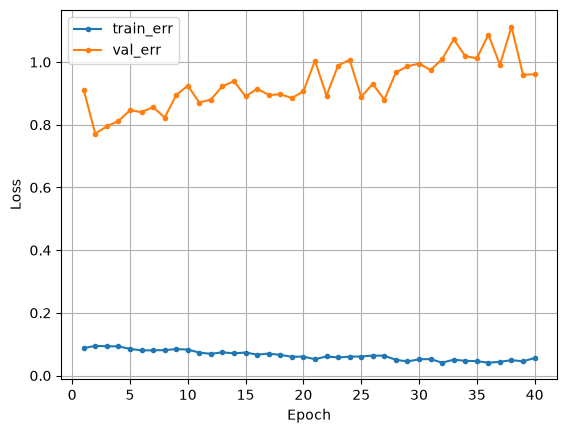

In [17]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)


In [ ]:
# 조기 종료
n_class = 10
model1= nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)


# 1. 조기 종료를 위한 변수 설정 ----------------
patience = 5   #오차가 몇번을 안줄어도 참을지 결정
best_loss = float('inf')
counter = 0
tr_loss_list, val_loss_list = [], []
for t in range(40):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


    # 2. 조기 종료 확인 -------------------
    if val_loss > best_loss: #개선이 되지않았으면 한번을 참아라 (오차가 줄지 않음)
        counter += 1  
        print(f'--> status, best_loss : {best_loss:4f}, counter : {counter}')
    else:  #개선이 됬으면 현재 오차 = 개선 오차
        best_loss = val_loss
        counter = 0
    # 3. 조기 종료 조건 확인 --------------------
    if counter >= patience:  #patience 5번보다 크면 학습하는걸 멈춰라
        print('Early Stopping!')
        break


Epoch 1, train loss : 0.7343, val loss : 0.5367
Epoch 2, train loss : 0.4652, val loss : 0.4763
Epoch 3, train loss : 0.4060, val loss : 0.4533
Epoch 4, train loss : 0.3707, val loss : 0.4293
Epoch 5, train loss : 0.3436, val loss : 0.4329
--> status, best_loss : 0.429292, counter : 1
Epoch 6, train loss : 0.3220, val loss : 0.4327
--> status, best_loss : 0.429292, counter : 2
Epoch 7, train loss : 0.3086, val loss : 0.4454
--> status, best_loss : 0.429292, counter : 3
Epoch 8, train loss : 0.2881, val loss : 0.4503
--> status, best_loss : 0.429292, counter : 4
Epoch 9, train loss : 0.2789, val loss : 0.4308
--> status, best_loss : 0.429292, counter : 5
Early Stopping!


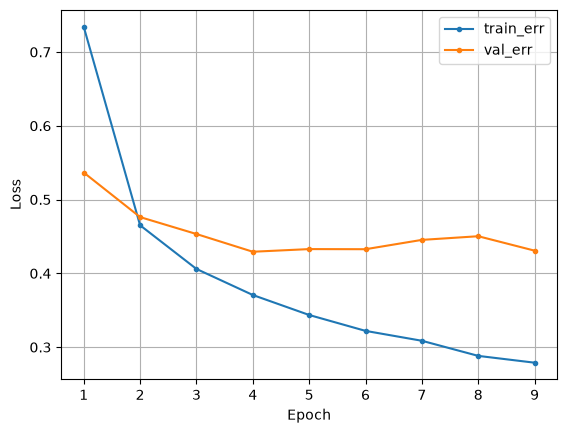

In [19]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [ ]:
# 드롭아웃
n_feature = 28 * 28
n_class = 10
dropout_rate = 0.4 #40%로 줄여라


model2 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512), nn.ReLU(),
            nn.Dropout(dropout_rate), #dropout 층이 새로생김
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)


Epoch 1, train loss : 1.0295, val loss : 0.6018
Epoch 2, train loss : 0.6297, val loss : 0.5135
Epoch 3, train loss : 0.5628, val loss : 0.4851
Epoch 4, train loss : 0.5215, val loss : 0.4608
Epoch 5, train loss : 0.4916, val loss : 0.4428
Epoch 6, train loss : 0.4721, val loss : 0.4426
Epoch 7, train loss : 0.4556, val loss : 0.4257
Epoch 8, train loss : 0.4355, val loss : 0.4191
Epoch 9, train loss : 0.4340, val loss : 0.4131
Epoch 10, train loss : 0.4119, val loss : 0.4206
Epoch 11, train loss : 0.4112, val loss : 0.3997
Epoch 12, train loss : 0.4002, val loss : 0.4137
Epoch 13, train loss : 0.3920, val loss : 0.4041
Epoch 14, train loss : 0.3892, val loss : 0.4065
Epoch 15, train loss : 0.3756, val loss : 0.4183
Epoch 16, train loss : 0.3768, val loss : 0.4005
Epoch 17, train loss : 0.3680, val loss : 0.4070
Epoch 18, train loss : 0.3639, val loss : 0.4045
Epoch 19, train loss : 0.3551, val loss : 0.4101
Epoch 20, train loss : 0.3586, val loss : 0.4047
Epoch 21, train loss : 0.3483

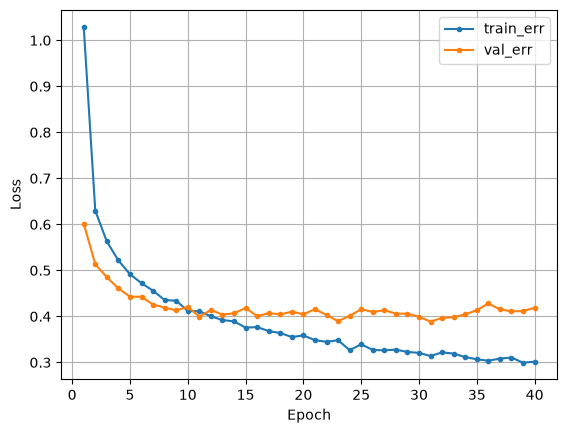

In [21]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)


In [ ]:
# 가중치 규제  optimizer 한테 weight_decay 주기
n_feature = 28 * 28
n_class = 10


model3 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001, weight_decay = 0.001)



Epoch 1, train loss : 0.7839, val loss : 0.6049
Epoch 2, train loss : 0.5213, val loss : 0.5428
Epoch 3, train loss : 0.4590, val loss : 0.4883
Epoch 4, train loss : 0.4285, val loss : 0.4565
Epoch 5, train loss : 0.4084, val loss : 0.4587
Epoch 6, train loss : 0.3857, val loss : 0.4556
Epoch 7, train loss : 0.3689, val loss : 0.4596
Epoch 8, train loss : 0.3554, val loss : 0.4751
Epoch 9, train loss : 0.3467, val loss : 0.4608
Epoch 10, train loss : 0.3335, val loss : 0.4650
Epoch 11, train loss : 0.3225, val loss : 0.4454
Epoch 12, train loss : 0.3112, val loss : 0.4272
Epoch 13, train loss : 0.3006, val loss : 0.4550
Epoch 14, train loss : 0.2946, val loss : 0.4502
Epoch 15, train loss : 0.2904, val loss : 0.4243
Epoch 16, train loss : 0.2799, val loss : 0.4423
Epoch 17, train loss : 0.2771, val loss : 0.4607
Epoch 18, train loss : 0.2693, val loss : 0.4531
Epoch 19, train loss : 0.2629, val loss : 0.4652
Epoch 20, train loss : 0.2590, val loss : 0.4395
Epoch 21, train loss : 0.2516

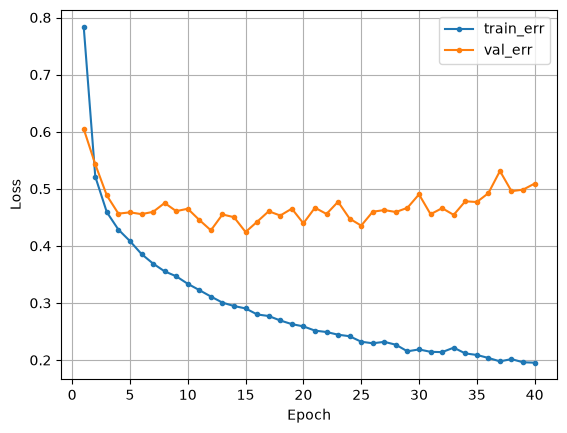

In [24]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)

